In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

df = pd.read_csv('/content/drive/MyDrive/NTI/project/Data/Agrofood_co2_emission.csv')
df.head()

,Area,Year,Savanna fires,Forest fires,Crop Residues,Rice Cultivation,Drained organic soils (CO2),Pesticides Manufacturing,Food Transport,Forestland,...,Manure Management,Fires in organic soils,Fires in humid tropical forests,On-farm energy use,Rural population,Urban population,Total Population - Male,Total Population - Female,total_emission,Average Temperature °C
0,Afghanistan,1990,14.7237,0.0557,205.6077,686.00,0.0,11.807483,63.1152,-2388.803,...,319.1763,0.0,0.0,NaN,9655167.0,2593947.0,5348387.0,5346409.0,2198.963539,0.536167
1,Afghanistan,1991,14.7237,0.0557,209.4971,678.16,0.0,11.712073,61.2125,-2388.803,...,342.3079,0.0,0.0,NaN,10230490.0,2763167.0,5372959.0,5372208.0,2323.876629,0.020667
2,Afghanistan,1992,14.7237,0.0557,196.5341,686.00,0.0,11.712073,53.3170,-2388.803,...,349.1224,0.0,0.0,NaN,10995568.0,2985663.0,6028494.0,6028939.0,2356.304229,-0.259583
3,Afghanistan,1993,14.7237,0.0557,230.8175,686.00,0.0,11.712073,54.3617,-2388.803,...,352.2947,0.0,0.0,NaN,11858090.0,3237009.0,7003641.0,7000119.0,2368.470529,0.101917
4,Afghanistan,1994,14.7237,0.0557,242.0494,705.60,0.0,11.712073,53.9874,-2388.803,...,367.6784,0.0,0.0,NaN,12690115.0,3482604.0,7733458.0,7722096.0,2500.768729,0.372250


In [4]:
df.shape

(6965, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6965 entries, 0 to 6964
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Area                             6965 non-null   object 
 1   Year                             6965 non-null   int64  
 2   Savanna fires                    6934 non-null   float64
 3   Forest fires                     6872 non-null   float64
 4   Crop Residues                    5576 non-null   float64
 5   Rice Cultivation                 6965 non-null   float64
 6   Drained organic soils (CO2)      6965 non-null   float64
 7   Pesticides Manufacturing         6965 non-null   float64
 8   Food Transport                   6965 non-null   float64
 9   Forestland                       6472 non-null   float64
 10  Net Forest conversion            6472 non-null   float64
 11  Food Household Consumption       6492 non-null   float64
 12  Food Retail         

In [6]:
df.isna().sum()

,0
Area,0
Year,0
Savanna fires,31
Forest fires,93
Crop Residues,1389
Rice Cultivation,0
Drained organic soils (CO2),0
Pesticides Manufacturing,0
Food Transport,0
Forestland,493


In [7]:
df.columns

Index(['Area', 'Year', 'Savanna fires', 'Forest fires', 'Crop Residues',
       'Rice Cultivation', 'Drained organic soils (CO2)',
       'Pesticides Manufacturing', 'Food Transport', 'Forestland',
       'Net Forest conversion', 'Food Household Consumption', 'Food Retail',
       'On-farm Electricity Use', 'Food Packaging',
       'Agrifood Systems Waste Disposal', 'Food Processing',
       'Fertilizers Manufacturing', 'IPPU', 'Manure applied to Soils',
       'Manure left on Pasture', 'Manure Management', 'Fires in organic soils',
       'Fires in humid tropical forests', 'On-farm energy use',
       'Rural population', 'Urban population', 'Total Population - Male',
       'Total Population - Female', 'total_emission',
       'Average Temperature °C'],
      dtype='object')

In [9]:
df.duplicated().sum()

np.int64(0)

In [12]:
numeric_cols = df.select_dtypes(include=['number']).columns

# Fill missing values with the median of each Area
for col in numeric_cols:
    df[col] = df.groupby('Area')[col].transform(lambda x: x.fillna(x.median()))

# If some countries have no data at all for a column, fill with global median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())


In [13]:
df.isna().sum()

,0
Area,0
Year,0
Savanna fires,0
Forest fires,0
Crop Residues,0
Rice Cultivation,0
Drained organic soils (CO2),0
Pesticides Manufacturing,0
Food Transport,0
Forestland,0


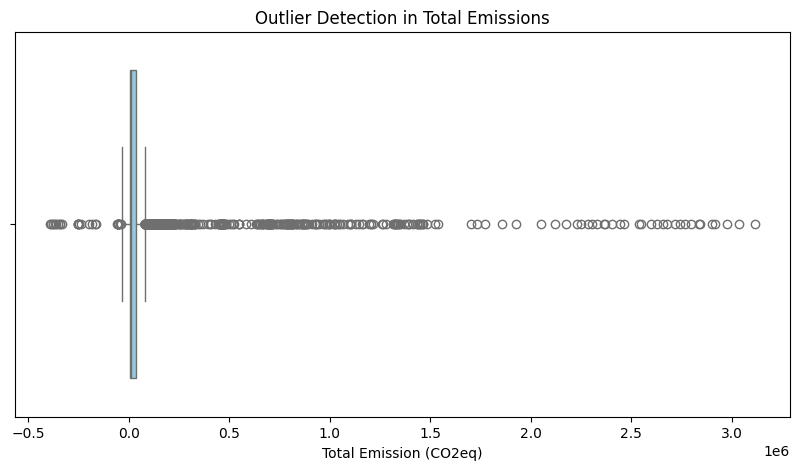

Top 5 Outliers (Highest Emissions):
                 Area  Year  total_emission
1324            China  2020    3.115114e+06
1417  China, mainland  2020    3.039089e+06
1323            China  2019    2.978585e+06
1322            China  2018    2.919286e+06
1416  China, mainland  2019    2.902693e+06


In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['total_emission'], color='skyblue')
plt.title('Outlier Detection in Total Emissions')
plt.xlabel('Total Emission (CO2eq)')
plt.show()

# Extracting the top 5 outlier

top_outliers = df.nlargest(5, 'total_emission')[['Area', 'Year', 'total_emission']]
print("Top 5 Outliers (Highest Emissions):")
print(top_outliers)

*The plot shows points far to the right. These are the "Outliers." Looking at the table, these are major countries.*

**Global Emission Trend Over Time**

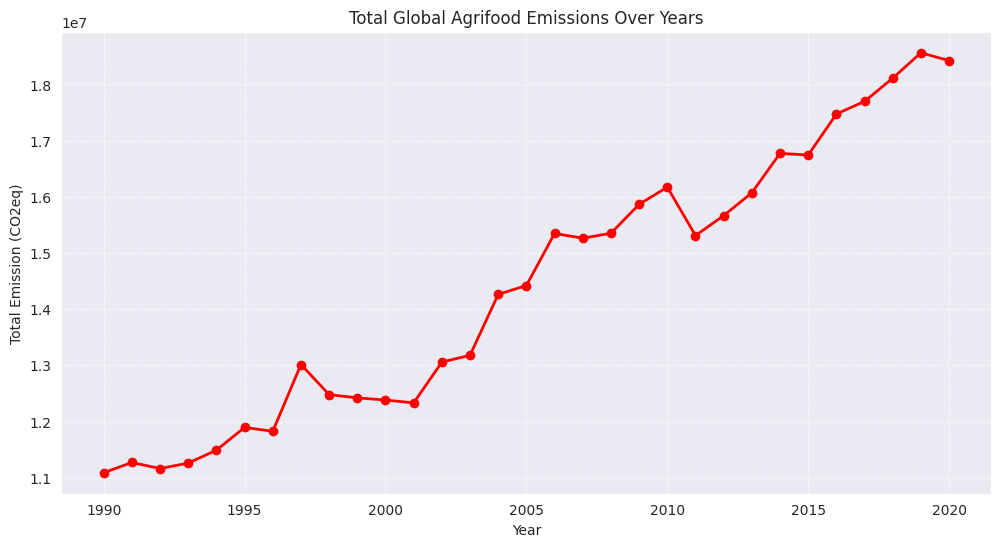

In [32]:

yearly_emissions = df.groupby('Year')['total_emission'].sum()

plt.figure(figsize=(12, 6))
yearly_emissions.plot(kind='line', marker='o', color='red', linewidth=2)
plt.title('Total Global Agrifood Emissions Over Years')
plt.ylabel('Total Emission (CO2eq)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

*The line shows a steady increase in emissions. This proves that despite global climate agreements, the agrifood sector's carbon footprint is still growing.*

**We want to know which activity pollutes the environment the most.**

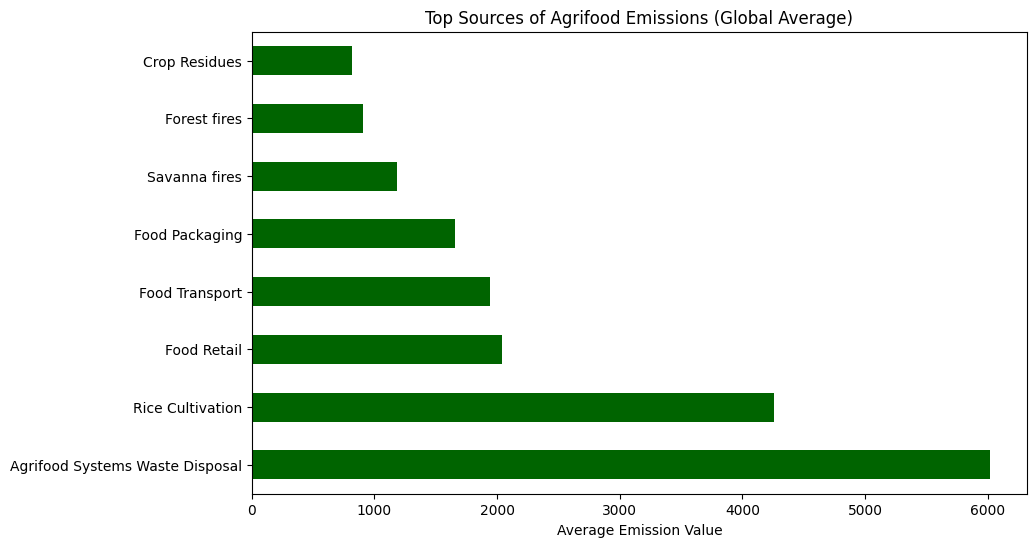

In [19]:
sources = ['Savanna fires', 'Forest fires', 'Crop Residues', 'Rice Cultivation',
           'Food Transport', 'Food Retail', 'Food Packaging', 'Agrifood Systems Waste Disposal']

source_totals = df[sources].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
source_totals.plot(kind='barh', color='darkgreen')
plt.title('Top Sources of Agrifood Emissions (Global Average)')
plt.xlabel('Average Emission Value')
plt.show()

*This chart identifies which specific activities contribute the most to CO2 "Waste Disposal" and "Rice Cultivation" is the most*

**Ranking Top 20 Countries by Cumulative Agrifood Emissions**

/tmp/ipython-input-847292824.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_emissions, x='total_emission', y='Area', palette='viridis')


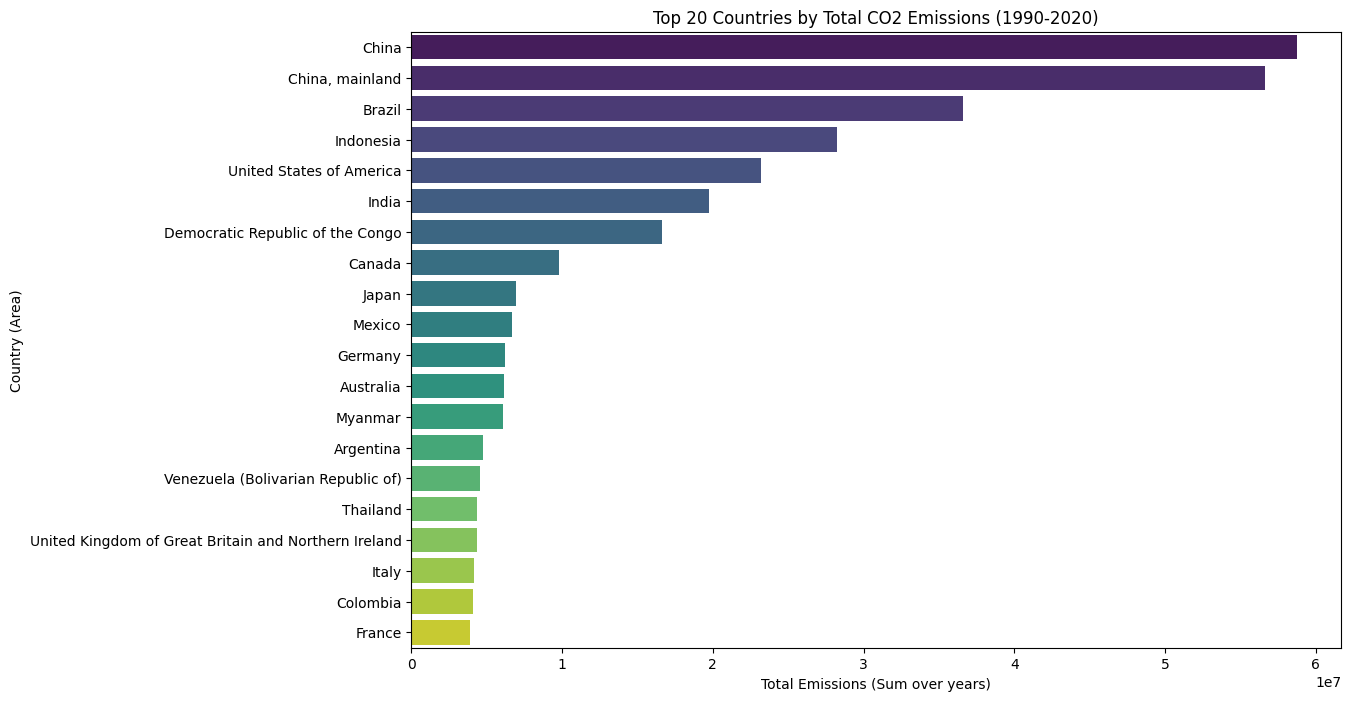

In [21]:
top_20_emissions = df.groupby('Area')['total_emission'].sum().sort_values(ascending=False).head(20).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(data=top_20_emissions, x='total_emission', y='Area', palette='viridis')

plt.title('Top 20 Countries by Total CO2 Emissions (1990-2020)')
plt.xlabel('Total Emissions (Sum over years)')
plt.ylabel('Country (Area)')
plt.show()

*his bar chart identifies the largest contributors to global CO2 emissions within the agrifood sector from 1990 to 2020. It highlights that a few large industrial and agricultural economies (like China, USA, and India) are responsible for the vast majority of the global carbon footprint.*

**China's Emission Growth vs. Global Average**

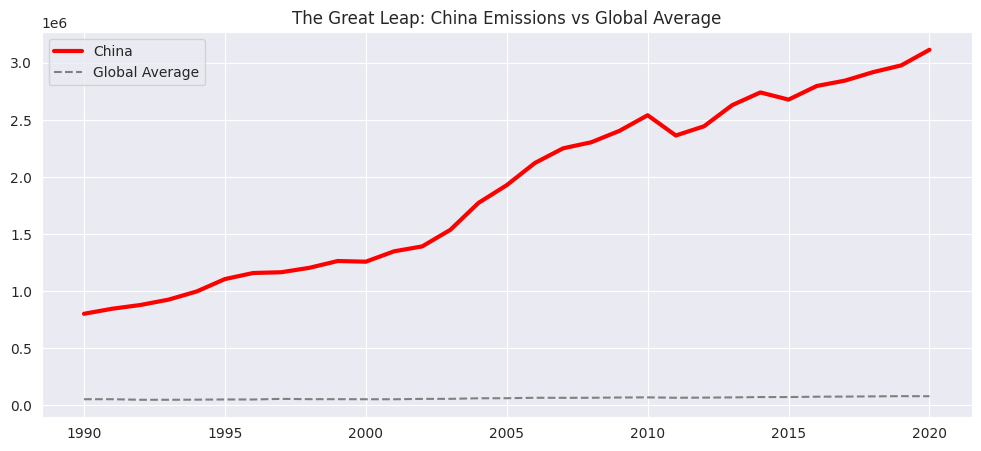

In [37]:
china_data = df[df['Area'] == 'China']
global_avg = df.groupby('Year')['total_emission'].mean()

plt.figure(figsize=(12, 5))
plt.plot(china_data['Year'], china_data['total_emission'], label='China', color='red', linewidth=3)
plt.plot(global_avg.index, global_avg.values, label='Global Average', color='gray', linestyle='--')
plt.title('The Great Leap: China Emissions vs Global Average')
plt.legend()
plt.show()

*China’s emissions skyrocketed after the year 2000, pulling far away from the global average*

**Breakdown of China's Emission Sources**

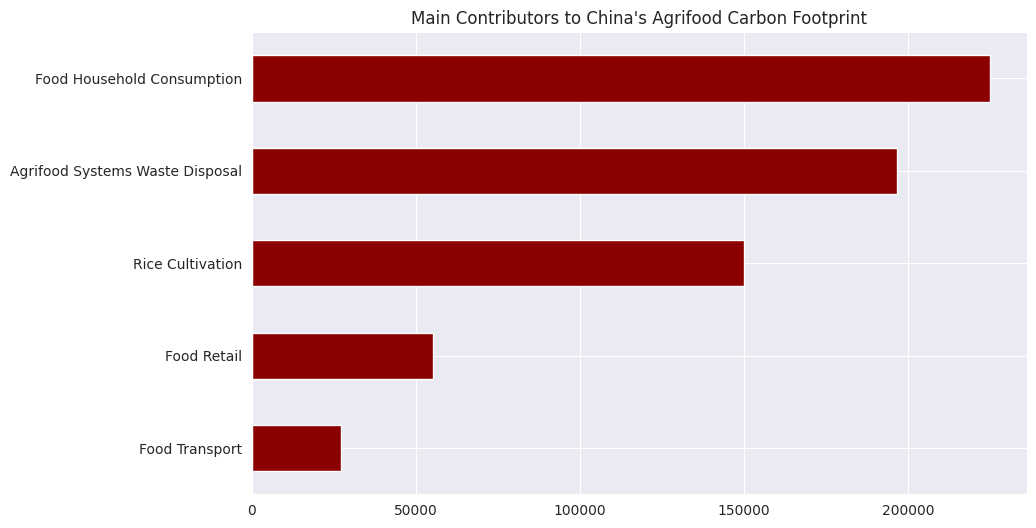

In [38]:
china_sources = china_data[['Rice Cultivation', 'Food Transport', 'Food Household Consumption',
                           'Agrifood Systems Waste Disposal', 'Food Retail']].mean()

plt.figure(figsize=(10, 6))
china_sources.sort_values().plot(kind='barh', color='darkred')
plt.title('Main Contributors to China\'s Agrifood Carbon Footprint')
plt.show()

*We can see which specific sectors (like Food Household Consumption or Waste) are the "Heaviest" in China*




**Urban Population Growth vs. Total Emissions in China**

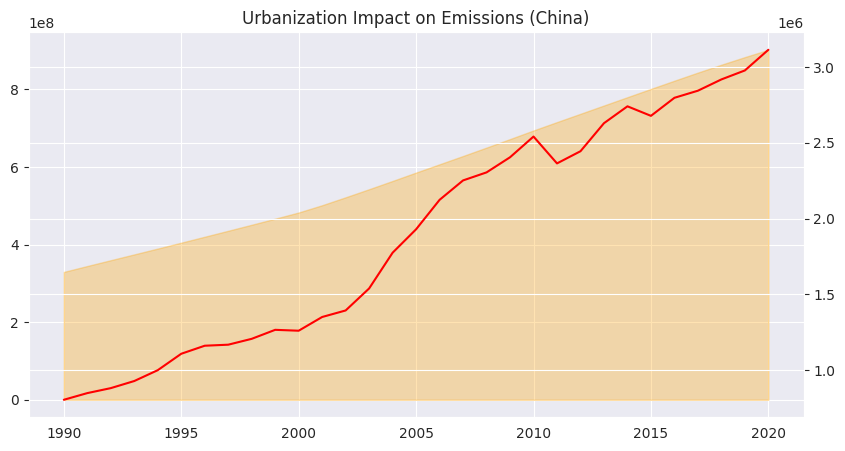

In [39]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.fill_between(china_data['Year'], china_data['Urban population'], color='orange', alpha=0.3, label='Urban Pop')
ax2.plot(china_data['Year'], china_data['total_emission'], color='red', label='Total Emission')
plt.title('Urbanization Impact on Emissions (China)')
plt.show()

*There is a direct correlation between China's massive urban migration and its emission levels*

**Forestland Change in China**



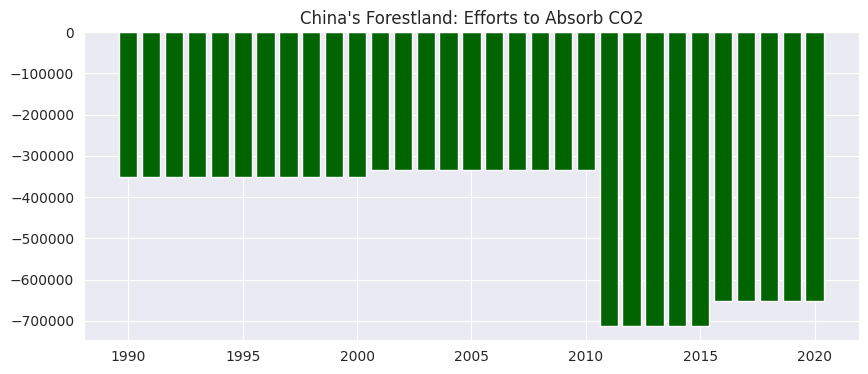

In [41]:
plt.figure(figsize=(10, 4))
plt.bar(china_data['Year'], china_data['Forestland'], color='darkgreen')
plt.title('China\'s Forestland: Efforts to Absorb CO2')
plt.show()

**Fertilizer Use Impact**

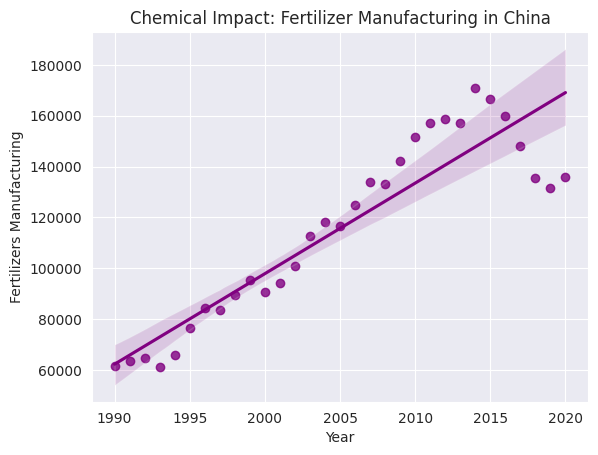

In [42]:
sns.regplot(data=china_data, x='Year', y='Fertilizers Manufacturing', color='purple')
plt.title('Chemical Impact: Fertilizer Manufacturing in China')
plt.show()

**Waste Disposal**
*Agrifood Systems Waste Disposal Trend*

/tmp/ipython-input-3777072015.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=china_data, x='Year', y='Agrifood Systems Waste Disposal', palette='viridis')


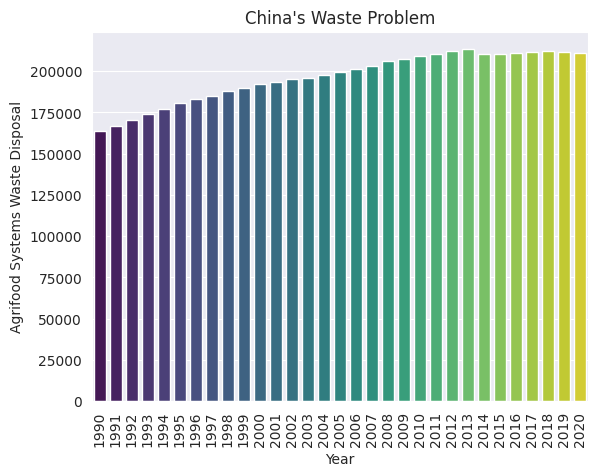

In [43]:
sns.barplot(data=china_data, x='Year', y='Agrifood Systems Waste Disposal', palette='viridis')
plt.xticks(rotation=90)
plt.title('China\'s Waste Problem')
plt.show()

**Food Packaging Emissions**

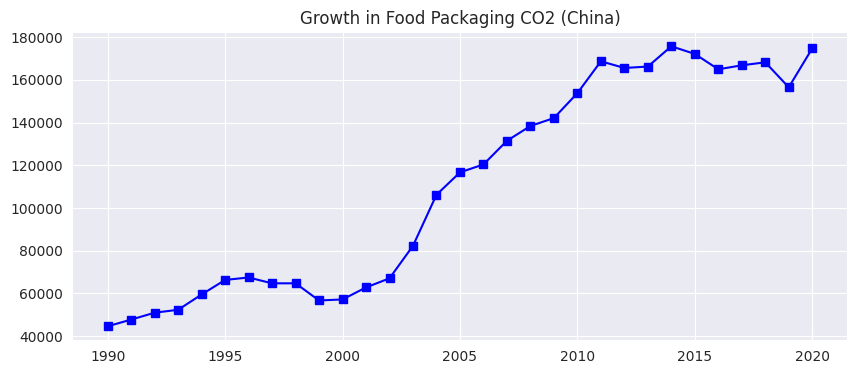

In [44]:
plt.figure(figsize=(10, 4))
plt.plot(china_data['Year'], china_data['Food Packaging'], marker='s', color='blue')
plt.title('Growth in Food Packaging CO2 (China)')
plt.show()

**China's Internal Correlation Matrix**

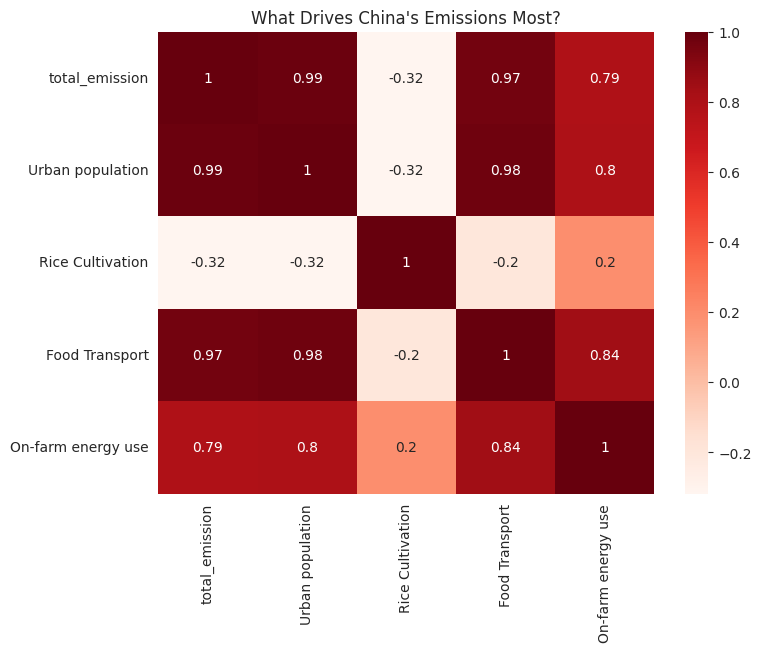

In [45]:
cols = ['total_emission', 'Urban population', 'Rice Cultivation', 'Food Transport', 'On-farm energy use']
plt.figure(figsize=(8, 6))
sns.heatmap(china_data[cols].corr(), annot=True, cmap='Reds')
plt.title('What Drives China\'s Emissions Most?')
plt.show()

In [46]:
df.to_csv('Agrofood_co2_emission_cleaned.csv', index=False)